Loaded 1024pi.out: angle=0.0°, Fx=3.217e+03, Fy=0.000e+00, components=x, n_points=51
maximum displacement (x): 27.13
sigma_noise added (x): 0.5426 (2.0% of maximum displacement)
realized experimental noise (x): 0.5252
sigma_noise prior: Exp(beta=0.3707)
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise.pdf


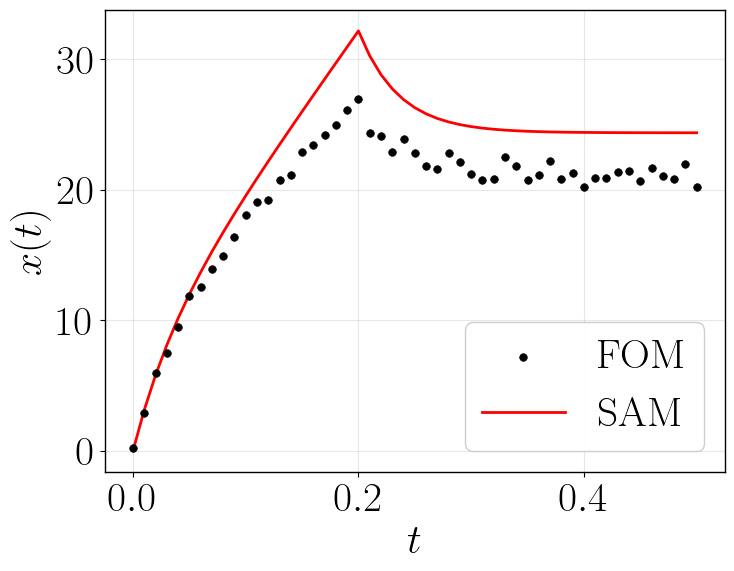

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\prior.pdf


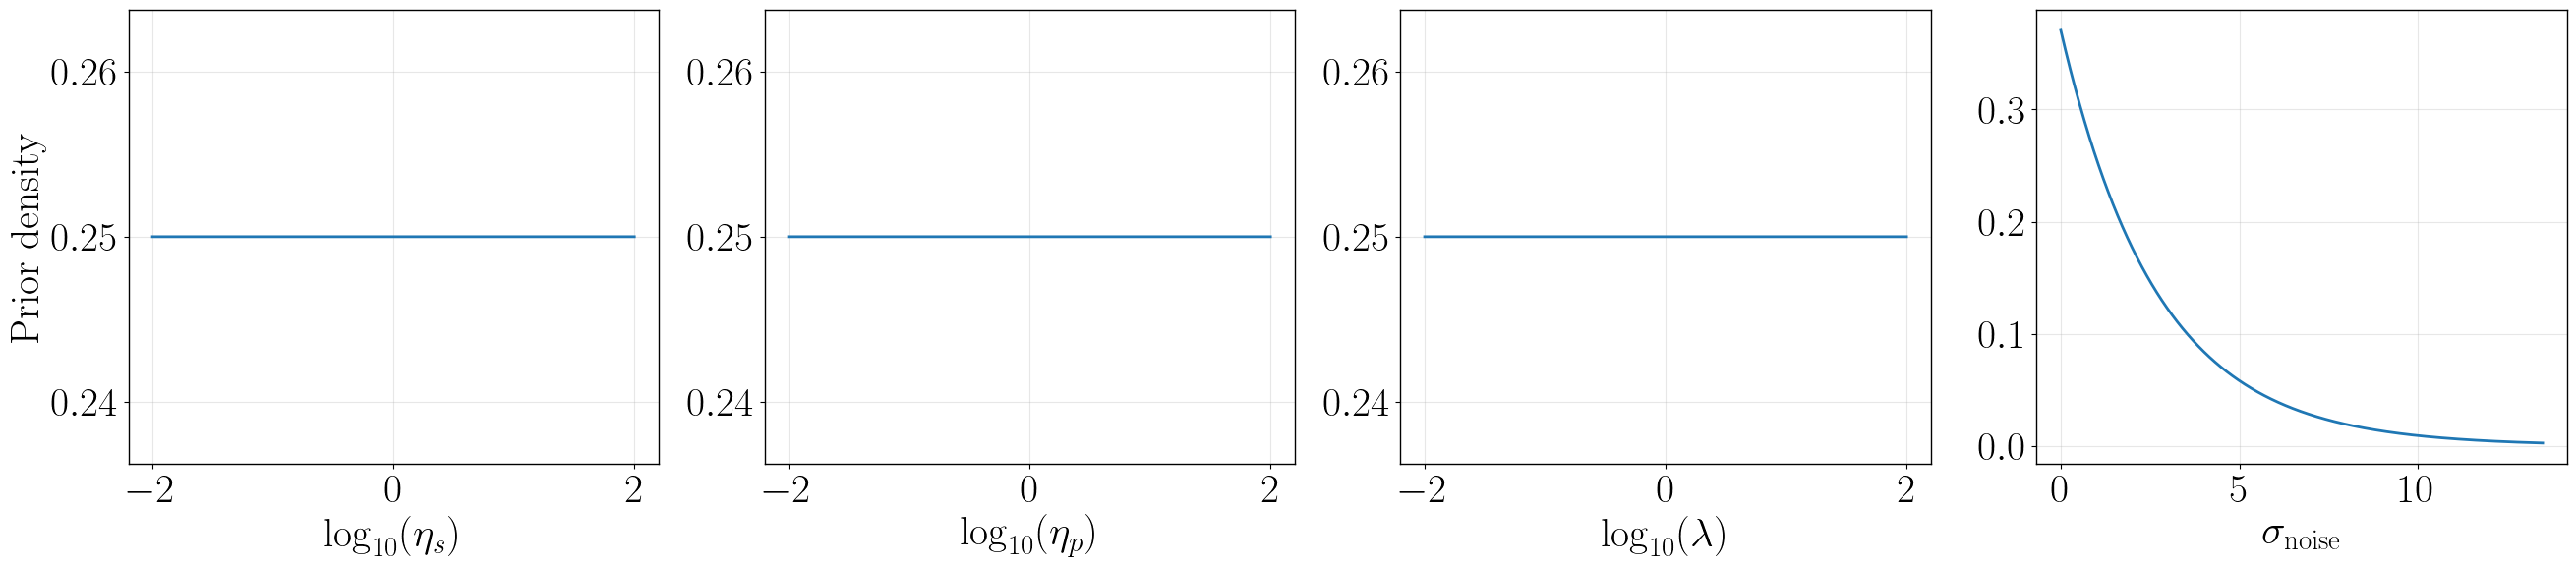


Preparing MCMC: ndim=4, walkers=8, steps=10000, init=kmeans, warmup=False

Initial walkers (physical):
  00: [27.18890265  0.30422304 20.44206138  1.22292504]
  01: [0.56952627 0.63320415 0.01799986 1.12517896]
  02: [ 6.15845988 50.94011903  3.36246364  0.20793179]
  03: [79.88944545 19.54548507  0.26188093  1.84879581]
  04: [ 0.02380726  3.76236114 10.77335474  0.48459572]
  05: [13.93982177  0.08108768 37.36667763  3.41046343]
  06: [12.46878666  0.03254277  1.65325235  1.76914782]
  07: [11.08048596  0.5938227  76.3470213   1.04854655]


100%|██████████| 10000/10000 [00:12<00:00, 812.97it/s]



MCMC Diagnostics Summary
Chains: 8  |  Samples/chain after burn-in: 7000  |  Total: 56000
----------------------------------------------------------------
Parameter                Mean            Std       Rhat
----------------------------------------------------------------
eta_s              4.6049e-01     3.2678e-02     1.0047
eta_p_eff          1.1469e+00     3.0281e-02     1.0035
lambda             8.7464e-02     4.2641e-03     1.0082
sigma_noise        6.4516e-01     6.8530e-02     1.0051
----------------------------------------------------------------
Mean Rhat                                        1.0054
Std Rhat                                         0.0018

Posterior-predictive adequacy (x, replicated data):
  Nominal central coverage of band:  95.0%
  ----------------------------------------------------------------
  series               cover     RMS z    max|z|    mean z
  x                   100.0%      0.91      1.98      0.05
Saved figure: c:\Users\paraj\Documents\ba

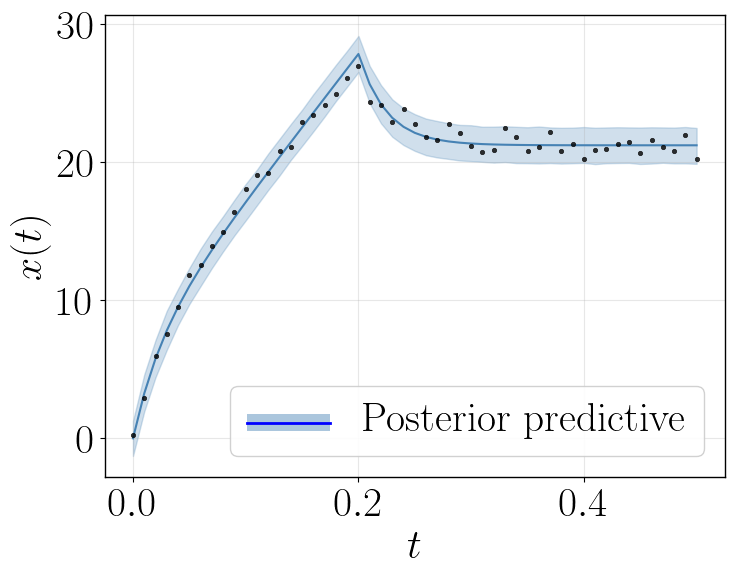

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\corner.pdf


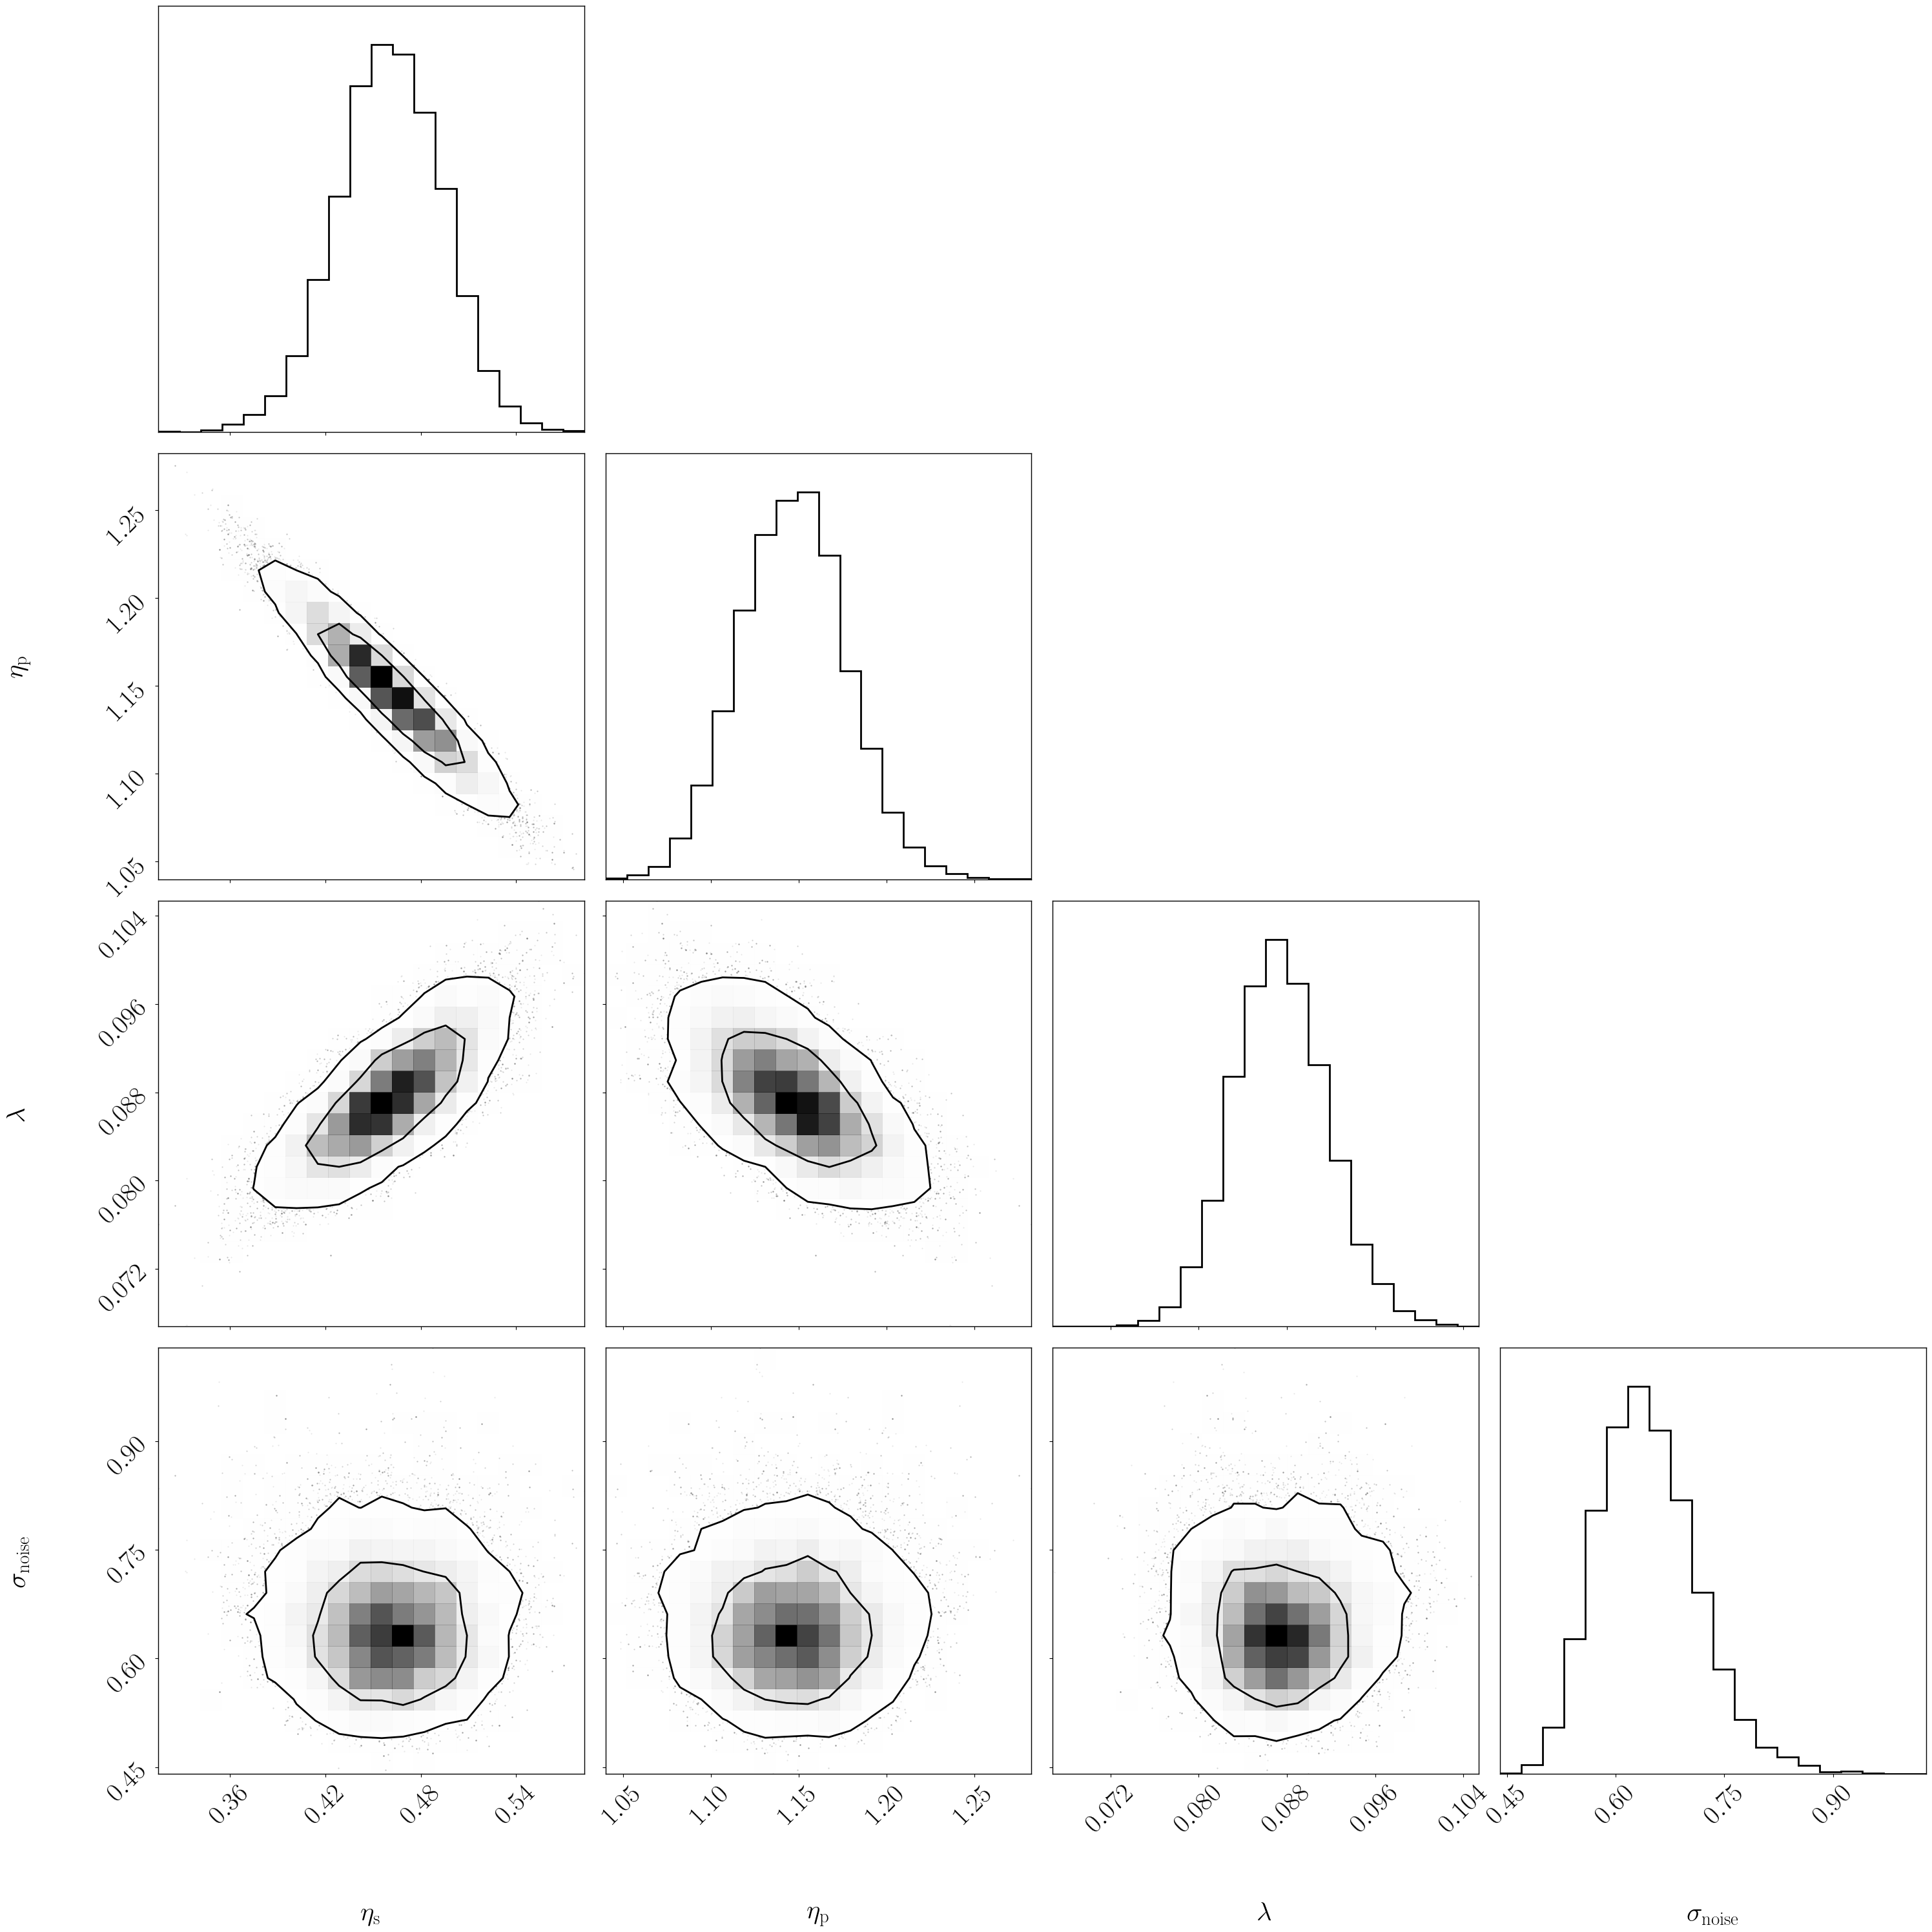

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\trace.pdf


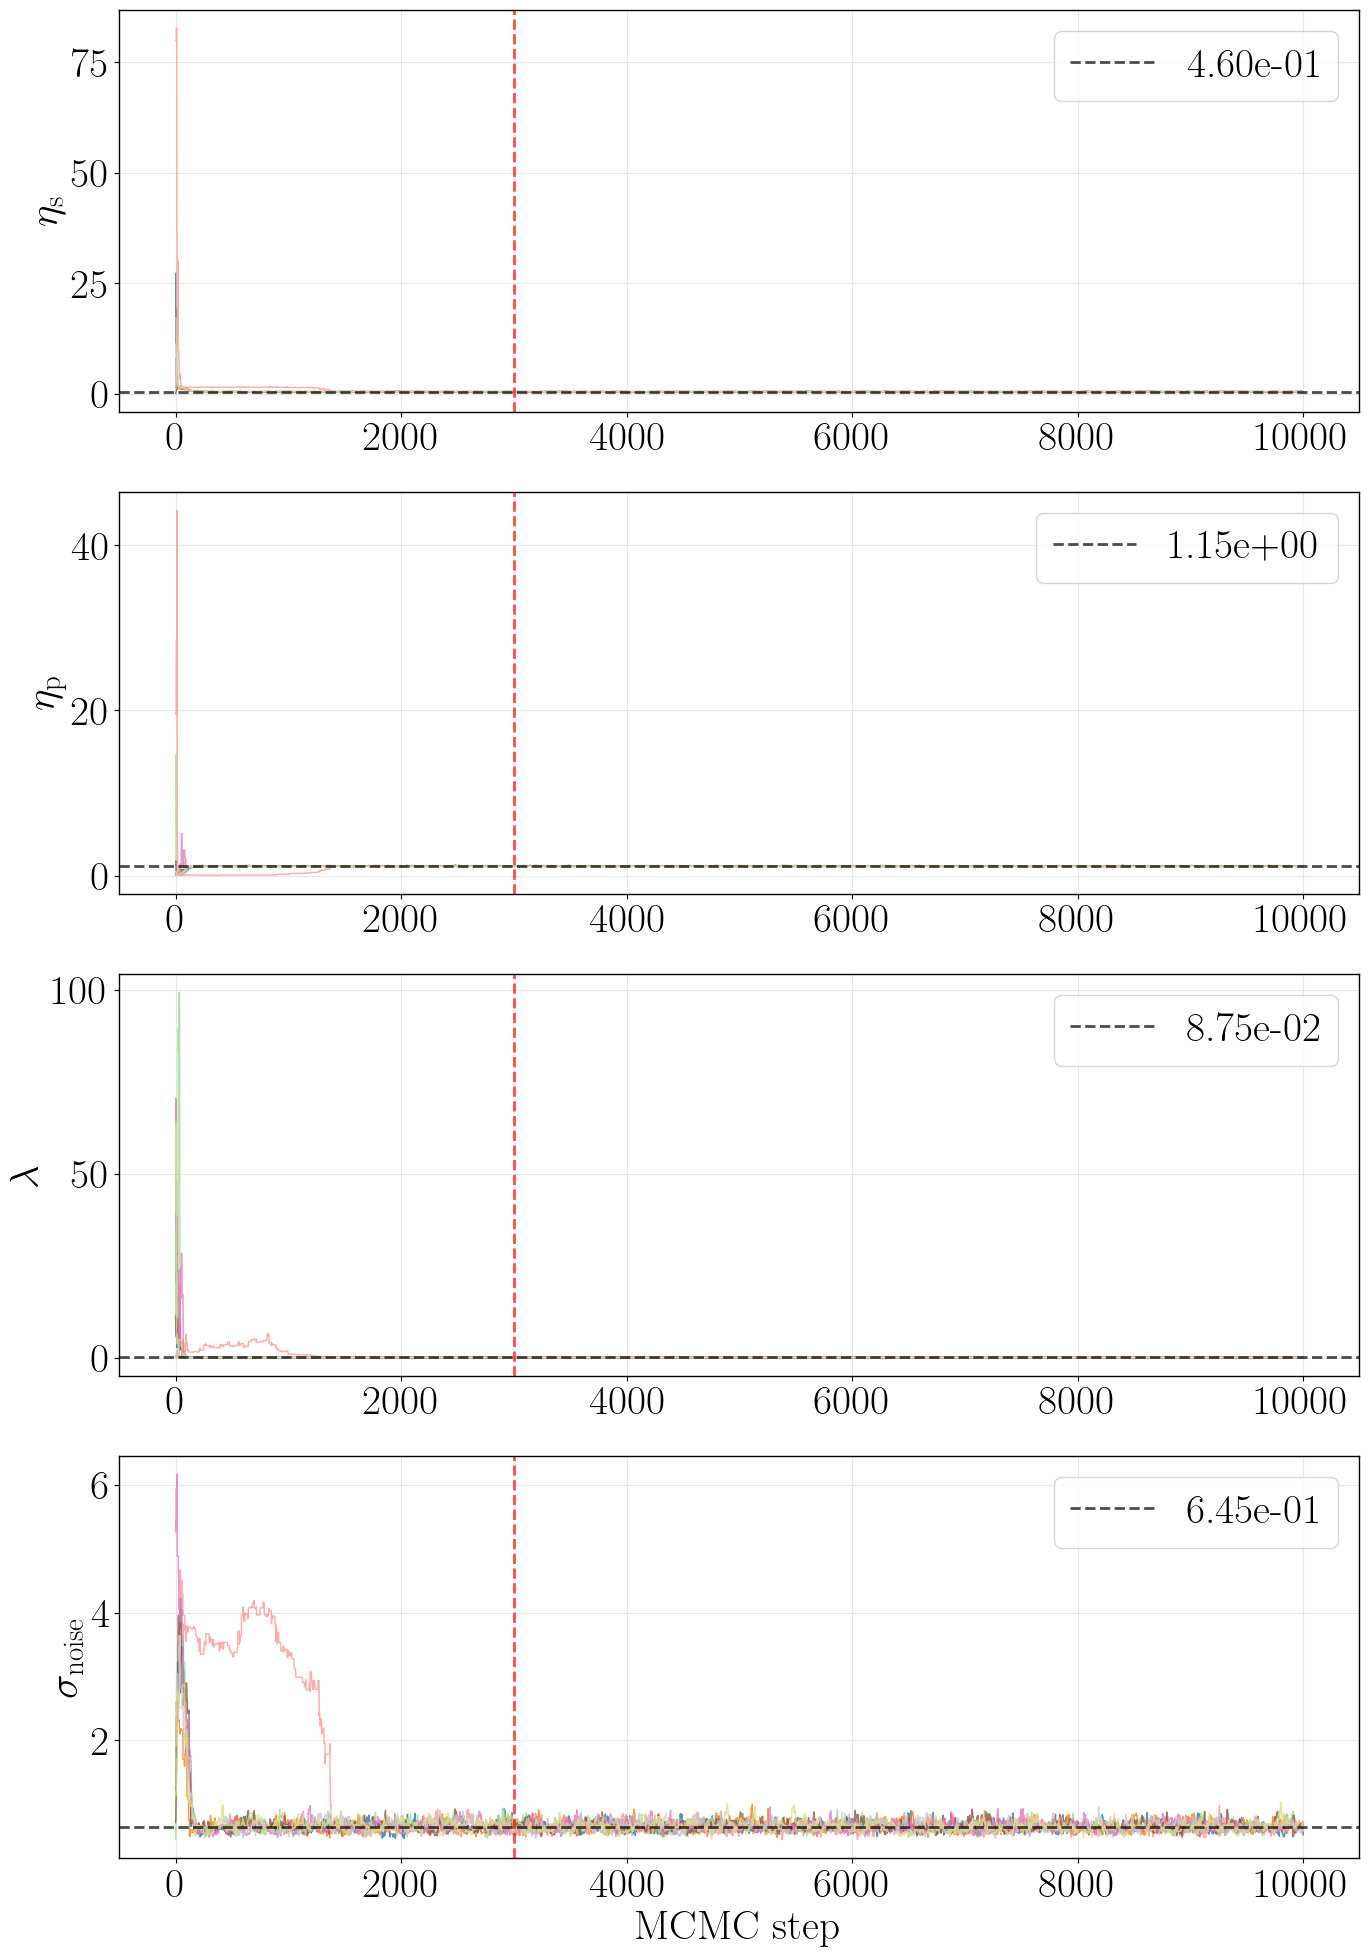

In [3]:
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import  InferenceProcedure

from packages.main import InferenceProcedure
import numpy as np

model = InferenceProcedure(
    force=1024*np.pi,
    material_model="viscoelastic",
    boundary_model="unbounded",
    theta=0,
    a=1.0,
    t_unload=0.2,
    sigma_noise_percent=2.0,
    sigma_bias = None,
    nsteps=10000,
    thin_factor=10)

model.load_data("data/nonlinear_viscoelastic/1024pi.out")
model.plot_data(theta_true=[0.5, 0.9, 0.1])
model.plot_prior()
model.run_mcmc(init_method="kmeans", warmup = False)
model.plot_results()